# Package Import

In [181]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone


from scipy.stats import skew, kurtosis

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

# Data Collection

## Read CSV

In [182]:
chili_df = pd.read_csv('dataset/cabai_rawit_combined.csv')

## Data Cleaning

In [183]:
chili_df['Date'] = pd.to_datetime(
    chili_df['Date'],
    format='%d/%m/%Y',
    errors='coerce'
)

chili_df = chili_df.dropna(subset=['Date'])
chili_df = chili_df.sort_values('Date').reset_index(drop=True)

chili_df = (
    chili_df
    .groupby('Date', as_index=False)
    .agg({'Price': 'mean'})
)

full_dates = pd.date_range(
    start=chili_df['Date'].min(),
    end=chili_df['Date'].max(),
    freq='D'
)

chili_df = (
    chili_df
    .set_index('Date')
    .reindex(full_dates)
    .rename_axis('Date')
    .reset_index()
)

chili_df['Price'] = chili_df['Price'].ffill()
chili_df = chili_df.dropna(subset=['Price']).reset_index(drop=True)

chili_df.head()

,Date,Price
0,2022-01-01,76357.0
1,2022-01-02,72846.0
2,2022-01-03,68357.0
3,2022-01-04,53462.0
4,2022-01-05,52692.0


In [184]:
chili_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1604 entries, 0 to 1603
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1604 non-null   datetime64[ns]
 1   Price   1604 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 25.2 KB


In [185]:
chili_df.shape

(1604, 2)

# Exploratory Data Analysis

## Descriptive Analysis

In [186]:
print(chili_df['Price'].describe())

count      1604.000000
mean      50756.263716
std       20009.038047
min       24077.000000
25%       34371.500000
50%       45220.000000
75%       64818.250000
max      114246.000000
Name: Price, dtype: float64


## Dispersion Analysis

In [187]:
std_price = chili_df['Price'].std()
var_price = chili_df['Price'].var()
min_price = chili_df['Price'].min()
max_price = chili_df['Price'].max()
range_price = max_price - min_price

print(f"Standard Deviation : {std_price:.2f}")
print(f"Variance           : {var_price:.2f}")
print(f"Min                : {min_price:.2f}")
print(f"Max                : {max_price:.2f}")
print(f"Range              : {range_price:.2f}")

Standard Deviation : 20009.04
Variance           : 400361603.56
Min                : 24077.00
Max                : 114246.00
Range              : 90169.00


## Outliers Analysis

In [188]:
Q1 = chili_df['Price'].quantile(0.25)
Q2 = chili_df['Price'].quantile(0.50)
Q3 = chili_df['Price'].quantile(0.75)

IQR = Q3 - Q1

print(f"Q1 : {Q1:.2f}")
print(f"Q2 : {Q2:.2f}")
print(f"Q3 : {Q3:.2f}")
print(f"IQR: {IQR:.2f}")

# Outlier bounds
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print(f"\nLower Bound : {lower_bound:.2f}")
print(f"Upper Bound : {upper_bound:.2f}")

Q1 : 34371.50
Q2 : 45220.00
Q3 : 64818.25
IQR: 30446.75

Lower Bound : -11298.62
Upper Bound : 110488.38


In [189]:
outliers = chili_df[
    (chili_df['Price'] < lower_bound) |
    (chili_df['Price'] > upper_bound)
]

print("Total Outliers:", len(outliers))

outlier_percentage = (
    len(outliers) / len(chili_df)
) * 100

print(f"Outlier Percentage: {outlier_percentage:.2f}%")

print("\nSample Outliers:")
print(outliers.head())

Total Outliers: 1
Outlier Percentage: 0.06%

Sample Outliers:
           Date     Price
1157 2025-03-03  114246.0


In [190]:
outliers[['Date', 'Price']]

,Date,Price
1157,2025-03-03,114246.0


## Distribution Analysis

In [191]:
price_clean = chili_df['Price'].dropna()

skewness = skew(price_clean)
kurt = kurtosis(price_clean)

print(f"Skewness : {skewness:.4f}")
print(f"Kurtosis : {kurt:.4f}")

# Interpretation
if skewness > 0:
    print("Distribution: Right-Skewed")
elif skewness < 0:
    print("Distribution: Left-Skewed")
else:
    print("Distribution: Symmetric")

Skewness : 0.8066
Kurtosis : -0.2420
Distribution: Right-Skewed


## Histogram

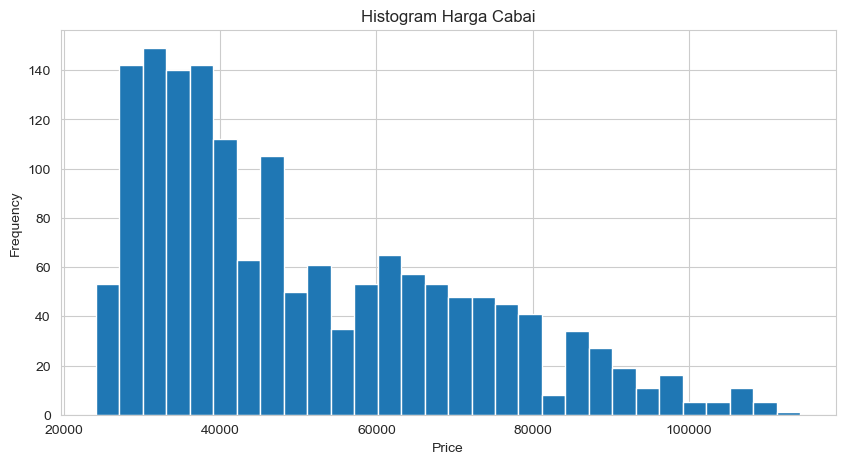

In [192]:
plt.figure(figsize=(10,5))

plt.hist(chili_df['Price'], bins=30)

plt.title("Histogram Harga Cabai")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

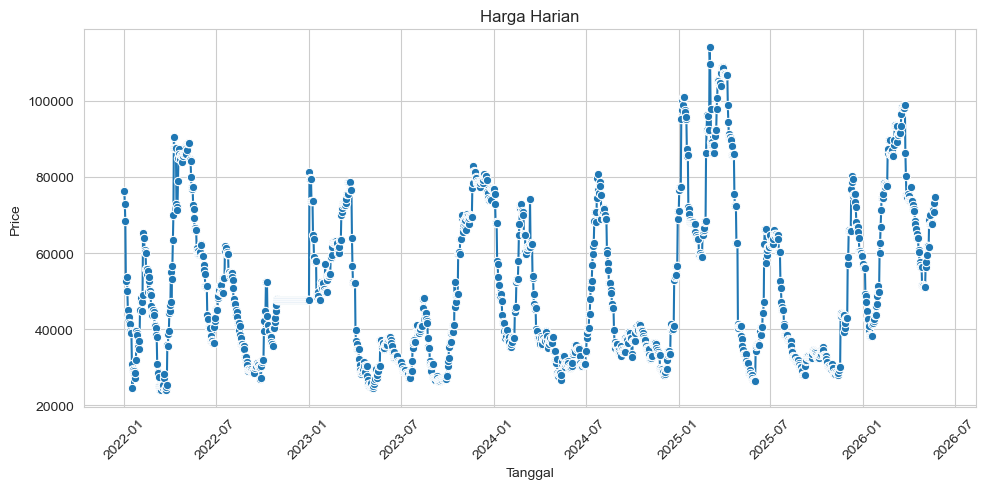

C:\Users\user\AppData\Local\Temp\ipykernel_22324\3557958552.py:21: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = chili_df.resample('M', on='Date').mean(numeric_only=True)


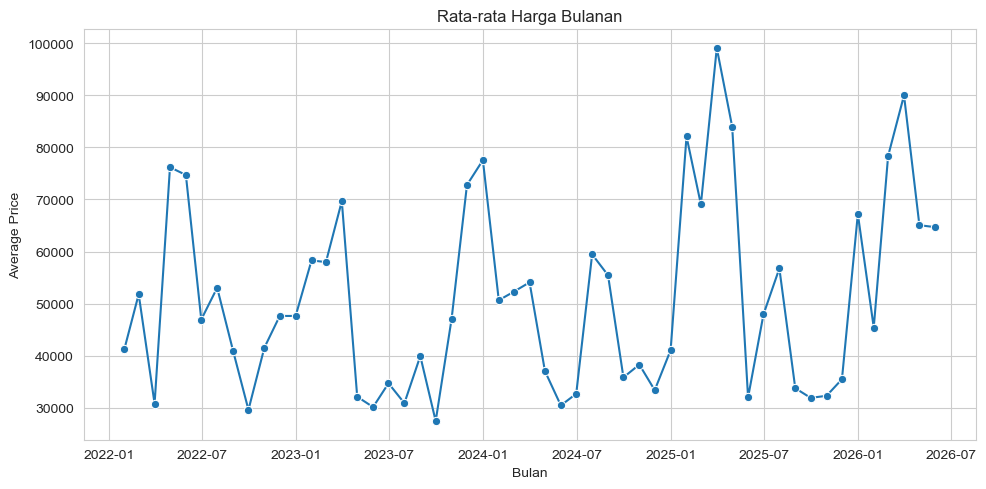

C:\Users\user\AppData\Local\Temp\ipykernel_22324\3557958552.py:36: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = chili_df.resample('Y', on='Date').mean(numeric_only=True)


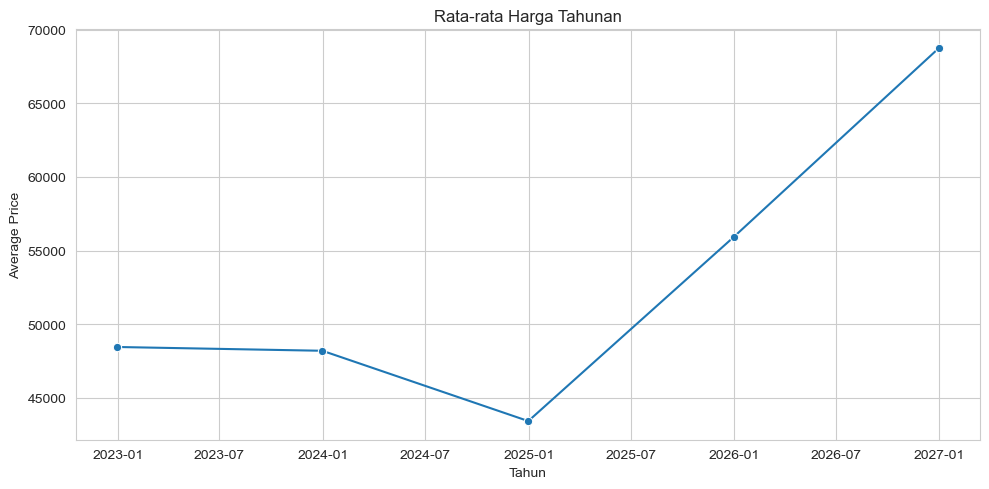

In [193]:
# Outlier Handling
# chili_df['Price_Smooth'] = chili_df['Price'].rolling(3).mean()

# =========================
# PLOT HARIAN
# =========================
plt.figure(figsize=(10,5))
sns.lineplot(data=chili_df, x='Date', y='Price', marker='o')

plt.title('Harga Harian')
plt.xlabel('Tanggal')
plt.ylabel('Price')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# =========================
# RESAMPLE BULANAN
# =========================
monthly = chili_df.resample('M', on='Date').mean(numeric_only=True)

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly, x=monthly.index, y='Price', marker='o')

plt.title('Rata-rata Harga Bulanan')
plt.xlabel('Bulan')
plt.ylabel('Average Price')

plt.tight_layout()
plt.show()

# =========================
# RESAMPLE TAHUNAN
# =========================
yearly = chili_df.resample('Y', on='Date').mean(numeric_only=True)

plt.figure(figsize=(10,5))
sns.lineplot(data=yearly, x=yearly.index, y='Price', marker='o')

plt.title('Rata-rata Harga Tahunan')
plt.xlabel('Tahun')
plt.ylabel('Average Price')

plt.tight_layout()
plt.show()

           Date    Price  Year Month
0    2022-01-01  76357.0  2022   Jan
1    2022-01-02  72846.0  2022   Jan
2    2022-01-03  68357.0  2022   Jan
3    2022-01-04  53462.0  2022   Jan
4    2022-01-05  52692.0  2022   Jan
...         ...      ...   ...   ...
1599 2026-05-19  71250.0  2026   May
1600 2026-05-20  70821.0  2026   May
1601 2026-05-21  73208.0  2026   May
1602 2026-05-22  74667.0  2026   May
1603 2026-05-23  74667.0  2026   May

[1604 rows x 4 columns]


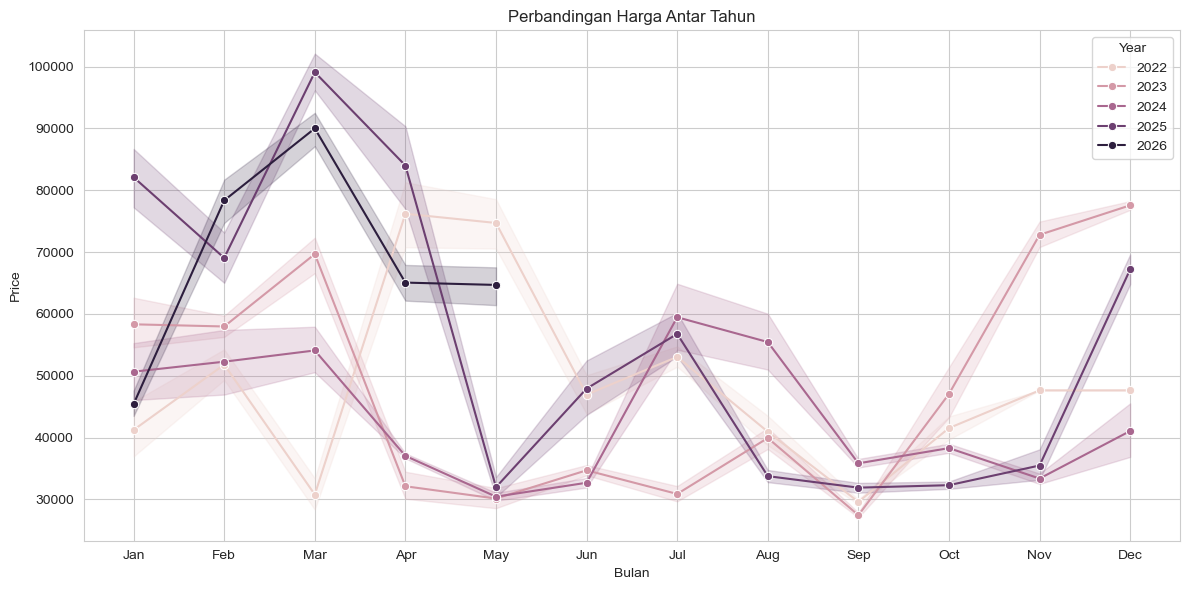

In [194]:
# AMBIL TAHUN DAN BULAN
chili_df['Year'] = chili_df['Date'].dt.year
chili_df['Month'] = chili_df['Date'].dt.strftime('%b')

print(chili_df)

# =========================
# VISUALIZATION
# =========================
sns.set_style("whitegrid")

plt.figure(figsize=(12,6))

sns.lineplot(
    data=chili_df,
    x='Month',
    y='Price',
    hue='Year',
    marker='o'
)

plt.title('Perbandingan Harga Antar Tahun')
plt.xlabel('Bulan')
plt.ylabel('Price')

plt.tight_layout()
plt.show()

## Data Preprocessing

### Feature Engineering

In [195]:
df = chili_df.copy()

horizon = 3

df['target_date'] = df['Date'].shift(-horizon)
df['target_price'] = df['Price'].shift(-horizon)

df['Year'] = df['target_date'].dt.year
df['Month'] = df['target_date'].dt.month
df['Day'] = df['target_date'].dt.day
df['DayOfWeek'] = df['target_date'].dt.dayofweek
df['WeekOfYear'] = df['target_date'].dt.isocalendar().week.astype(float)

df['month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

df['dow_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)

lags = [1, 2, 3, 7, 14, 21, 30]

for lag in lags:
    df[f'lag_{lag}'] = df['Price'].shift(lag)

df['rolling_mean_3'] = df['Price'].shift(1).rolling(3).mean()
df['rolling_mean_7'] = df['Price'].shift(1).rolling(7).mean()
df['rolling_mean_14'] = df['Price'].shift(1).rolling(14).mean()
df['rolling_mean_30'] = df['Price'].shift(1).rolling(30).mean()

df['rolling_std_7'] = df['Price'].shift(1).rolling(7).std()
df['rolling_std_14'] = df['Price'].shift(1).rolling(14).std()

df['rolling_min_7'] = df['Price'].shift(1).rolling(7).min()
df['rolling_max_7'] = df['Price'].shift(1).rolling(7).max()

df['diff_1_lagged'] = df['Price'].shift(1).diff(1)
df['diff_7_lagged'] = df['Price'].shift(1).diff(7)
df['pct_change_7_lagged'] = df['Price'].shift(1).pct_change(7)

df = df.dropna().reset_index(drop=True)

df.head()

,Date,Price,Year,Month,target_date,target_price,Day,DayOfWeek,WeekOfYear,month_sin,...,rolling_mean_7,rolling_mean_14,rolling_mean_30,rolling_std_7,rolling_std_14,rolling_min_7,rolling_max_7,diff_1_lagged,diff_7_lagged,pct_change_7_lagged
0,2022-01-31,36875.0,2022.0,2.0,2022-02-03,48167.0,3.0,3.0,5.0,0.866025,...,36309.857143,32225.214286,41372.033333,2794.109842,4789.886383,31929.0,39583.0,-557.0,6217.0,0.217507
1,2022-02-01,45154.0,2022.0,2.0,2022-02-04,44885.0,4.0,4.0,5.0,0.866025,...,37016.428571,33097.214286,40055.966667,2019.697738,4403.736860,34800.0,39583.0,2075.0,4946.0,0.154906
2,2022-02-02,47462.0,2022.0,2.0,2022-02-05,47192.0,5.0,5.0,5.0,0.866025,...,37812.285714,34205.142857,39132.900000,3644.039275,5323.078084,34800.0,45154.0,8279.0,5571.0,0.140742
3,2022-02-03,48167.0,2022.0,2.0,2022-02-06,49000.0,6.0,6.0,5.0,0.866025,...,39021.142857,35497.857143,38436.400000,5182.520379,6184.777452,34800.0,47462.0,2308.0,8462.0,0.216974
4,2022-02-04,44885.0,2022.0,2.0,2022-02-07,65333.0,7.0,0.0,6.0,0.866025,...,40402.142857,36866.928571,38259.900000,6207.201340,6732.888161,34800.0,48167.0,705.0,9667.0,0.251091


# Model Training

In [196]:
features = [
    'lag_1',
    'lag_2',
    'lag_3',
    'lag_7',
    'lag_14',
    'lag_21',
    'lag_30',

    'rolling_mean_3',
    'rolling_mean_7',
    'rolling_mean_14',
    'rolling_mean_30',

    'rolling_std_7',
    'rolling_std_14',

    'rolling_min_7',
    'rolling_max_7',

    'diff_1_lagged',
    'diff_7_lagged',
    'pct_change_7_lagged',

    'month_sin',
    'month_cos',
    'dow_sin',
    'dow_cos',

    'DayOfWeek',
    'WeekOfYear'
]

target = 'target_price'

In [197]:
split_date = '2025-05-01'

train_df = df[df['target_date'] < split_date].copy()
test_df = df[df['target_date'] >= split_date].copy()

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

print("Train period:", train_df['target_date'].min(), "sampai", train_df['target_date'].max())
print("Test period :", test_df['target_date'].min(), "sampai", test_df['target_date'].max())

Train shape: (1183, 24)
Test shape : (388, 24)
Train period: 2022-02-03 00:00:00 sampai 2025-04-30 00:00:00
Test period : 2025-05-01 00:00:00 sampai 2026-05-23 00:00:00


## Modeling

In [198]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

In [199]:
baseline_pred = test_df['lag_3']

baseline_result = {
    'Model': 'Naive Baseline',
    'MAE': mean_absolute_error(y_test, baseline_pred),
    'RMSE': rmse(y_test, baseline_pred),
    'MAPE': mape(y_test, baseline_pred)
}

baseline_result

{'Model': 'Naive Baseline',
 'MAE': 5471.131443298969,
 'RMSE': np.float64(7787.25229769385),
 'MAPE': np.float64(10.379627081070746)}

In [200]:
models = {
    'XGBoost': XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42
    ),

    'RandomForest': RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ),

    'LightGBM': LGBMRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1
    ),

    'CatBoost': CatBoostRegressor(
        iterations=500,
        learning_rate=0.03,
        depth=4,
        loss_function='RMSE',
        verbose=0,
        random_state=42
    )
}

In [201]:
tscv = TimeSeriesSplit(n_splits=5)

cv_scores = []

for model_name, model in models.items():

    for fold, (train_idx, val_idx) in enumerate(tscv.split(train_df)):

        fold_train = train_df.iloc[train_idx]
        fold_val = train_df.iloc[val_idx]

        X_fold_train = fold_train[features]
        y_fold_train = fold_train[target]

        X_fold_val = fold_val[features]
        y_fold_val = fold_val[target]

        model_fold = clone(model)
        model_fold.fit(X_fold_train, y_fold_train)

        val_pred = model_fold.predict(X_fold_val)

        cv_scores.append({
            'Model': model_name,
            'Fold': fold + 1,
            'MAE': mean_absolute_error(y_fold_val, val_pred),
            'RMSE': rmse(y_fold_val, val_pred),
            'MAPE': mape(y_fold_val, val_pred)
        })

cv_scores_df = pd.DataFrame(cv_scores)
cv_scores_df

,Model,Fold,MAE,RMSE,MAPE
0,XGBoost,1,6887.114253,9001.263948,16.804295
1,XGBoost,2,5762.947523,6736.065757,15.999817
2,XGBoost,3,7112.907241,9184.995510,11.516992
3,XGBoost,4,3266.842074,4437.837887,7.519500
4,XGBoost,5,11347.180917,15505.340613,15.345956
5,RandomForest,1,6164.465756,7888.230944,13.961736
6,RandomForest,2,4822.068021,5794.265140,12.601611
7,RandomForest,3,5876.111844,7248.697326,9.925337
8,RandomForest,4,3378.017171,4408.911100,8.046566
9,RandomForest,5,9556.085202,13063.005264,12.908968


In [202]:
cv_summary = (
    cv_scores_df
    .groupby('Model')[['MAE', 'RMSE', 'MAPE']]
    .mean()
    .sort_values('MAPE')
)

cv_summary

,MAE,RMSE,MAPE
Model,,,
RandomForest,5959.349599,7680.621955,11.488844
CatBoost,6372.408652,8481.632755,12.290075
XGBoost,6875.398402,8973.100743,13.437312
LightGBM,6831.403612,8661.943253,13.567269


In [203]:
final_results = []
final_predictions = {}

for model_name, model in models.items():

    final_model = clone(model)
    final_model.fit(X_train, y_train)

    test_pred = final_model.predict(X_test)

    final_predictions[model_name] = test_pred

    final_results.append({
        'Model': model_name,
        'MAE': mean_absolute_error(y_test, test_pred),
        'RMSE': rmse(y_test, test_pred),
        'MAPE': mape(y_test, test_pred)
    })

final_results.append(baseline_result)

final_results_df = pd.DataFrame(final_results).sort_values('MAPE')
final_results_df

,Model,MAE,RMSE,MAPE
3,CatBoost,4032.536953,6016.355452,7.626269
0,XGBoost,4283.935270,6325.520998,7.887517
2,LightGBM,4535.850316,6570.537708,8.196112
1,RandomForest,4738.335354,6898.150307,8.709623
4,Naive Baseline,5471.131443,7787.252298,10.379627


In [204]:
best_model_name = final_results_df.iloc[0]['Model']

print("Best model:", best_model_name)

if best_model_name == 'Naive Baseline':
    best_model = None
    print("Model ML belum mengalahkan baseline. Jangan deploy dulu.")
else:
    best_model = clone(models[best_model_name])
    best_model.fit(X_train, y_train)

Best model: CatBoost


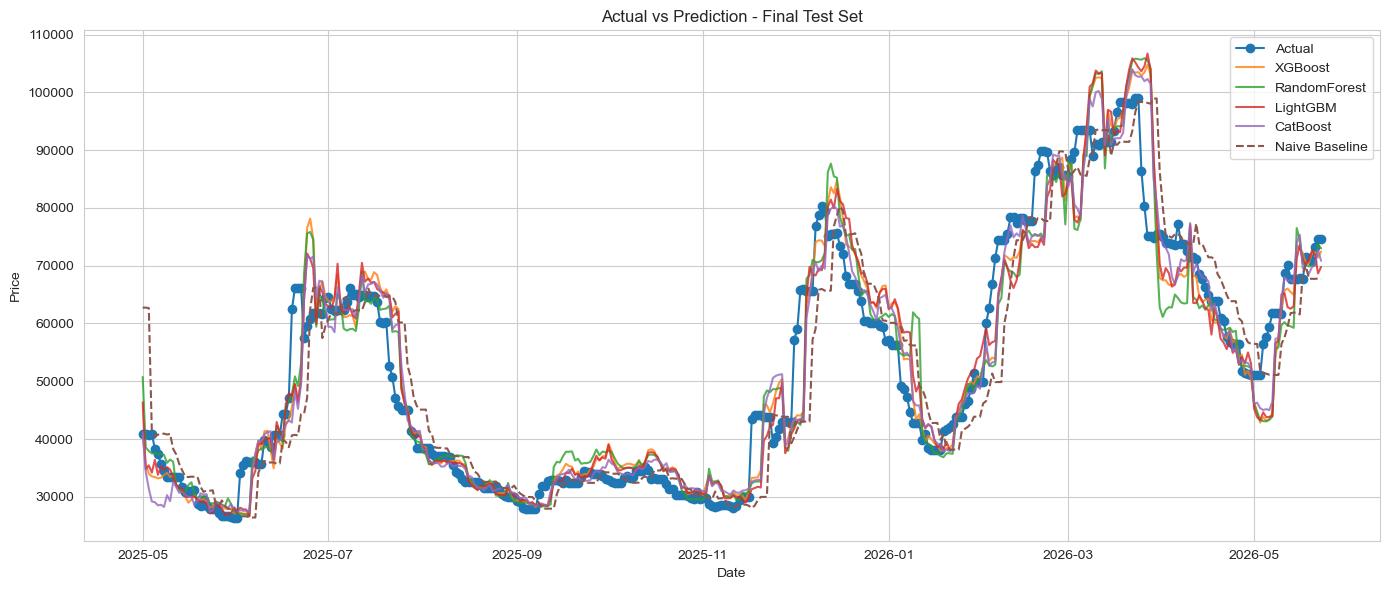

In [205]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_df['target_date'],
    y_test.values,
    label='Actual',
    marker='o'
)

for model_name, pred in final_predictions.items():
    plt.plot(
        test_df['target_date'],
        pred,
        label=model_name,
        alpha=0.8
    )

plt.plot(
    test_df['target_date'],
    baseline_pred.values,
    label='Naive Baseline',
    linestyle='--'
)

plt.title('Actual vs Prediction - Final Test Set')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

,Feature,Importance
0,lag_1,33.050928
1,lag_2,11.428516
7,rolling_mean_3,10.101879
8,rolling_mean_7,6.378815
2,lag_3,6.217698
16,diff_7_lagged,5.341201
14,rolling_max_7,5.224999
17,pct_change_7_lagged,4.852072
23,WeekOfYear,3.185217
13,rolling_min_7,2.356039


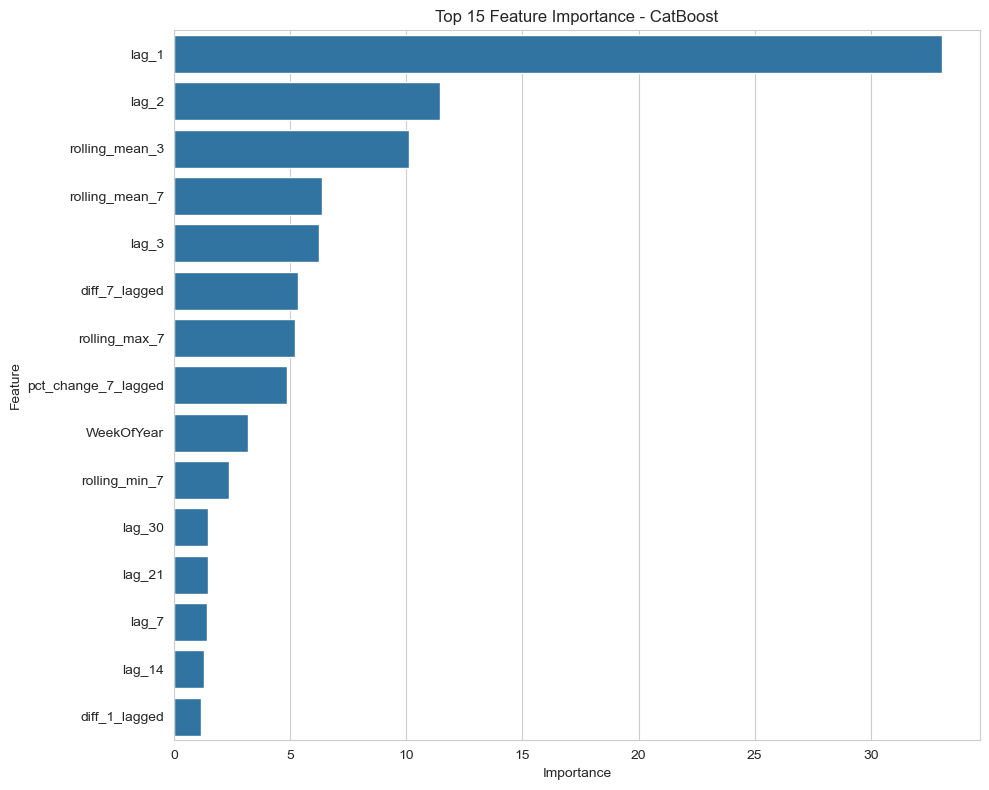

In [206]:
if best_model is not None:

    importance_df = pd.DataFrame({
        'Feature': features,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    display(importance_df)

    plt.figure(figsize=(10, 8))
    sns.barplot(
        data=importance_df.head(15),
        x='Importance',
        y='Feature'
    )

    plt.title(f'Top 15 Feature Importance - {best_model_name}')
    plt.tight_layout()
    plt.show()